# Soluzione del problema del Mammino Minimo utilizzando la Programmazione Lineare

## Definizione del problema (da un nodo origine ad un nodo destinazione)

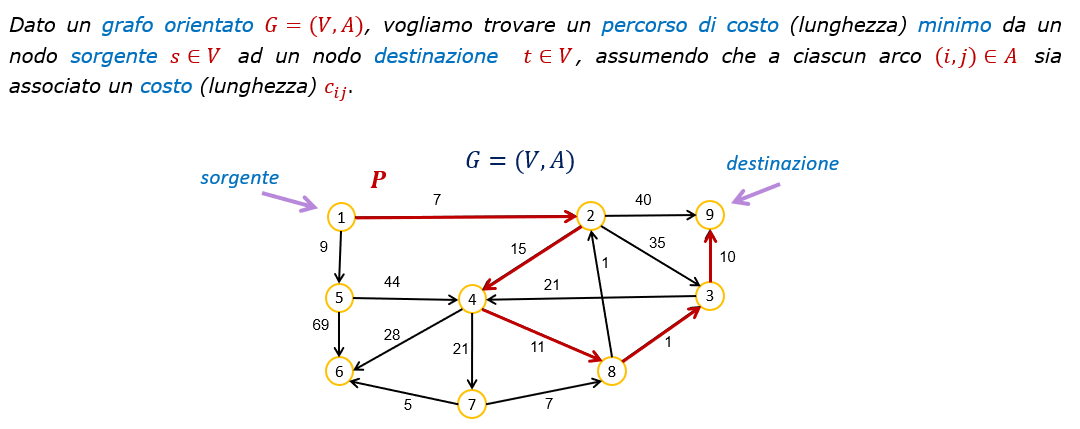

# Formulazione del problema

### $$ min \sum_{(i,j) \in A} c_{ij} x_{ij}$$
### $$ \sum_{j \in \delta^+(i)} x_{ij} - \sum_{j \in \delta^-(i)} x_{ji} =
\begin{cases}
1 \quad if \quad i = s\\
0 \quad if \quad i \neq s,t\\
-1 \quad if \quad i = t
\end{cases} $$
### $$ 0 \leq x_{ij} \leq 1 $$

dove:
- V $\rightarrow$ insieme dei nodi del grafo
- A $\rightarrow$ insieme degli archi del grafo
- $c_{ij}$ $\rightarrow$ costo associato all'arco $(i,j) \in A$
- s $\rightarrow$ nodo origine
- t $\rightarrow$ nodo destinazione



### Legge il file contenente l'elenco degli archi e crea
- Il nodo origine: **ori**
- Il nodo destinazione: **dest**
- Una lista **Nodi** contenente l'elenco dei nodi del grafo
- Un Dictionary **Archi** = $\{(i,j) : \ c_{ij} \quad (i,j) \in A\}$

In [1]:
file = open("shortest_path_example.dat", "r")

line = file.readlines()

line[0].strip("\n").split(" ")

line[3].strip("\n").split(" ")

['1', '2', '7.0']

In [2]:
file = open("shortest_path_example.dat", "r")

line = file.readlines()
ori = int(line[0].strip("\n").split(" ")[2])
dest = int(line[1].strip("\n").split(" ")[2])

Nodi = []
Archi = {}
for k in range(3, len(line)):
    
    row = line[k].strip("\n").split(" ")
    Archi[(int(row[0]),int(row[1]))] = float(row[2])
    
    if (int(row[0]) in Nodi) == False :
        Nodi.append(int(row[0]))
    if (int(row[1]) in Nodi) == False :
        Nodi.append(int(row[1]))    
        
Nodi.sort()

print("nodi =", Nodi)
print("archi =", Archi)
print("nodo origine =", ori)
print("nodo destinazione =", dest)

nodi = [1, 2, 3, 4, 5, 6, 7, 8, 9]
archi = {(1, 2): 7.0, (1, 5): 9.0, (2, 3): 35.0, (2, 4): 15.0, (2, 9): 40.0, (3, 4): 21.0, (3, 9): 10.0, (4, 6): 28.0, (4, 7): 21.0, (4, 8): 11.0, (5, 4): 44.0, (5, 6): 69.0, (7, 6): 5.0, (7, 8): 7.0, (8, 2): 1.0, (8, 3): 1.0}
nodo origine = 1
nodo destinazione = 9


### Importa la libreria GRB, inizializza il problema e definisce le variabili

In [3]:
import gurobipy as gp
from gurobipy import GRB

import numpy as np

# Inizializza il modelo
mod = gp.Model('SP')

# Crea le varibili di decisione
Xvars = mod.addVars(Archi.keys(), obj=Archi, vtype=GRB.CONTINUOUS, name='x', lb = 0.0, ub = 1.0)
Xvars

Set parameter Username
Academic license - for non-commercial use only - expires 2023-07-14


{(1, 2): <gurobi.Var *Awaiting Model Update*>,
 (1, 5): <gurobi.Var *Awaiting Model Update*>,
 (2, 3): <gurobi.Var *Awaiting Model Update*>,
 (2, 4): <gurobi.Var *Awaiting Model Update*>,
 (2, 9): <gurobi.Var *Awaiting Model Update*>,
 (3, 4): <gurobi.Var *Awaiting Model Update*>,
 (3, 9): <gurobi.Var *Awaiting Model Update*>,
 (4, 6): <gurobi.Var *Awaiting Model Update*>,
 (4, 7): <gurobi.Var *Awaiting Model Update*>,
 (4, 8): <gurobi.Var *Awaiting Model Update*>,
 (5, 4): <gurobi.Var *Awaiting Model Update*>,
 (5, 6): <gurobi.Var *Awaiting Model Update*>,
 (7, 6): <gurobi.Var *Awaiting Model Update*>,
 (7, 8): <gurobi.Var *Awaiting Model Update*>,
 (8, 2): <gurobi.Var *Awaiting Model Update*>,
 (8, 3): <gurobi.Var *Awaiting Model Update*>}

### Vincolo sul nodo origine

In [4]:
origin = mod.addConstr(gp.quicksum(Xvars[i,j] for i,j in Xvars.keys() if i == ori) == 1)

In [5]:
mod.write("sp.lp")

### Vincolo sul nodo destinazione

In [6]:
destination = mod.addConstr(gp.quicksum(Xvars[i,j] for i,j in Xvars.keys() if j == dest) == 1)

In [7]:
mod.write("sp.lp")

### Vincoli sui nodi intermedi

In [8]:
node = mod.addConstrs(gp.quicksum(Xvars[i,j] for i,j in Xvars.keys() if j == node) - 
                      gp.quicksum(Xvars[j,i] for j,i in Xvars.keys() if j == node) == 0
                      for node in Nodi if node != ori and node != dest)

In [9]:
mod.write("sp.lp")

### Risolve il problema

In [10]:
#mod.ModelSense = 1
#mod.setParam("OutputFlag", 0)

mod.optimize()

Gurobi Optimizer version 9.5.1 build v9.5.1rc2 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 9 rows, 16 columns and 32 nonzeros
Model fingerprint: 0xadc706f4
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 7e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 5 rows and 7 columns
Presolve time: 0.01s
Presolved: 4 rows, 9 columns, 18 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.7000000e+01   2.000000e+00   0.000000e+00      0s
       3    4.4000000e+01   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.02 seconds (0.00 work units)
Optimal objective  4.400000000e+01


### Preleva la soluzione e la stampa

In [11]:
if mod.status == GRB.OPTIMAL:

    # print solution
    #print('\nValore ottimale: %g \n' % mod.objVal)
    print("\nValore ottimale:", mod.objVal)
    
    X = mod.getAttr('x', Xvars)
    print(X)
    print("Archi del percorso ottimo")
    for i,j in Xvars.keys():
        if X[i,j] > 0 :
            print(i,j)


Valore ottimale: 44.0
{(1, 2): 1.0, (1, 5): 0.0, (2, 3): 0.0, (2, 4): 1.0, (2, 9): 0.0, (3, 4): 0.0, (3, 9): 1.0, (4, 6): 0.0, (4, 7): 0.0, (4, 8): 1.0, (5, 4): 0.0, (5, 6): 0.0, (7, 6): 0.0, (7, 8): 0.0, (8, 2): 0.0, (8, 3): 1.0}
Archi del percorso ottimo
1 2
2 4
3 9
4 8
8 3


## Definizione del problema (da un nodo origine a tutti gli altri nodi)

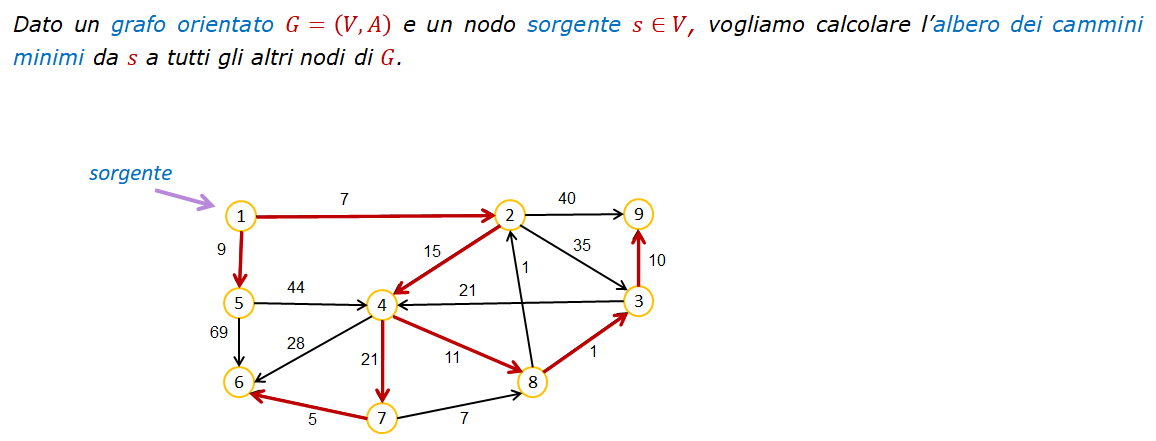

### Cambia l'upper bpund di tutte le variabili

In [12]:
for i,j in Xvars.keys() :
    Xvars[i,j].UB = len(Nodi)-1

### Elimina i vincoli e li sostituisce con i vincoli del nuovo modello

In [13]:
mod.remove(origin)
mod.remove(destination)
mod.remove(node)

# vincolo sul nodo origine
origin = mod.addConstr(gp.quicksum(Xvars[i,j] for i,j in Xvars.keys() if i == ori) == len(Nodi) -1)

# vincoli sugli altri nodi
node = mod.addConstrs(gp.quicksum(Xvars[i,j] for i,j in Xvars.keys() if j == node) - 
                      gp.quicksum(Xvars[j,i] for j,i in Xvars.keys() if j == node) == 1
                      for node in Nodi if node != ori)

### Risolve il problema

In [14]:
mod.optimize()

Gurobi Optimizer version 9.5.1 build v9.5.1rc2 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 9 rows, 16 columns and 32 nonzeros
Model fingerprint: 0xaaddf644
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 7e+01]
  Bounds range     [8e+00, 8e+00]
  RHS range        [1e+00, 8e+00]
Presolve removed 2 rows and 2 columns
Presolve time: 0.01s
Presolved: 7 rows, 14 columns, 28 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    9.3954000e+01   6.002000e+00   0.000000e+00      0s
       5    2.4000000e+02   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.01 seconds (0.00 work units)
Optimal objective  2.400000000e+02


### Preleva la soluzione e la stampa

In [15]:
if mod.status == GRB.OPTIMAL:

    # print solution
    print('\nValore ottimale: %g \n' % mod.objVal)
    
    X = mod.getAttr('x', Xvars)
    
    print("Archi del percorso ottimo")
    for i,j in Xvars.keys():
        if X[i,j] > 0 :
            print(i,j)


Valore ottimale: 240 

Archi del percorso ottimo
1 2
1 5
2 4
3 9
4 7
4 8
7 6
8 3
